# Model Implementation - XGBoost Classifer

## Imports

In [50]:
import os 
import sys
import platform

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import dump, load
import json
from pathlib import Path

from xgboost import XGBClassifier

import sklearn
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve 
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

from sklearn.inspection import permutation_importance
import shap

In [4]:
PROJECT_ROOT = Path.cwd().resolve().parent

save_dir = PROJECT_ROOT / 'reports' / 'figures' / '03_model_implementation_xgb'
save_art = PROJECT_ROOT / 'reports' / 'artifacts' / '03_model_implementation_xgb' 

## Data

In [5]:
data_path = PROJECT_ROOT / "data" / "data_preprocessed.csv"

data = pd.read_csv(data_path)

data.head()

,months_as_customer,policy_deductable,policy_annual_premium,umbrella_limit,incident_type,collision_type,incident_severity,authorities_contacted,property_damage,total_claim_amount,fraud_reported,injury_share,vehicle_share,property_share,claim_to_premium,claim_to_deductible,has_umbrella_policy
0,328,1000,1406.91,0,Single Vehicle Collision,Side Collision,Major Damage,Police,YES,71610,1,0.090909,0.727273,0.181818,50.898778,71.610,0
1,228,2000,1197.22,5000000,Vehicle Theft,No Collision,Minor Damage,Police,Not recorded,5070,1,0.153846,0.692308,0.153846,4.234811,2.535,1
2,134,2000,1413.14,5000000,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NO,34650,0,0.222222,0.666667,0.111111,24.519864,17.325,1
3,256,2000,1415.74,6000000,Single Vehicle Collision,Front Collision,Major Damage,Police,Not recorded,63400,1,0.100000,0.800000,0.100000,44.782234,31.700,1
4,228,1000,1583.91,6000000,Vehicle Theft,No Collision,Minor Damage,Police,NO,6500,0,0.200000,0.700000,0.100000,4.103769,6.500,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   months_as_customer     1000 non-null   int64  
 1   policy_deductable      1000 non-null   int64  
 2   policy_annual_premium  1000 non-null   float64
 3   umbrella_limit         1000 non-null   int64  
 4   incident_type          1000 non-null   object 
 5   collision_type         1000 non-null   object 
 6   incident_severity      1000 non-null   object 
 7   authorities_contacted  1000 non-null   object 
 8   property_damage        1000 non-null   object 
 9   total_claim_amount     1000 non-null   int64  
 10  fraud_reported         1000 non-null   int64  
 11  injury_share           1000 non-null   float64
 12  vehicle_share          1000 non-null   float64
 13  property_share         1000 non-null   float64
 14  claim_to_premium       1000 non-null   float64
 15  claim

## Categorical Features

I convert object columns to pandas 'category' dtype so that XGBoost can handle categorical features natively via `enable_categorical = True`

In [7]:
X = data.drop(['fraud_reported'], axis = 1)
y = data['fraud_reported']

In [8]:
print(f'X contains {X.shape[0]} rows and {X.shape[1]} columns.')

X contains 1000 rows and 16 columns.


In [9]:
y.shape

(1000,)

In [10]:
cat_features = X.select_dtypes('object').columns

X_cat = X.copy()

X_cat[cat_features] = X[cat_features].astype('category')

In [11]:
X_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   months_as_customer     1000 non-null   int64   
 1   policy_deductable      1000 non-null   int64   
 2   policy_annual_premium  1000 non-null   float64 
 3   umbrella_limit         1000 non-null   int64   
 4   incident_type          1000 non-null   category
 5   collision_type         1000 non-null   category
 6   incident_severity      1000 non-null   category
 7   authorities_contacted  1000 non-null   category
 8   property_damage        1000 non-null   category
 9   total_claim_amount     1000 non-null   int64   
 10  injury_share           1000 non-null   float64 
 11  vehicle_share          1000 non-null   float64 
 12  property_share         1000 non-null   float64 
 13  claim_to_premium       1000 non-null   float64 
 14  claim_to_deductible    1000 non-null   fl

## Test and Train Set Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_cat, y, test_size = 0.1, stratify = y, random_state = 42)

## XGBoost Classifier

In [13]:
scale_weight = (y_train == 0).sum() / (y_train  == 1).sum()

In [14]:
xgb_clf = XGBClassifier(enable_categorical = True, 
                       scale_pos_weight = scale_weight,
                       tree_method = 'hist', 
                       eval_metric = 'aucpr',
                       random_state = 42, 
                       n_jobs = -1)

### GridSearchCV

In [15]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

xgb_params = {
    'n_estimators': [300, 600, 1000],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'min_child_weight': [5, 10],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    #'reg_lambda': [1.0, 5.0]
    
}


grid_xgb = GridSearchCV(xgb_clf,
                       xgb_params,
                       cv = cv,
                       scoring = 'average_precision',
                       verbose = 1,
                       n_jobs = -1)


grid_xgb.fit(X_train, y_train)


Fitting 5 folds for each of 486 candidates, totalling 2430 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [5, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages

In [16]:
best_xgb = grid_xgb.best_estimator_
best_params = grid_xgb.best_params_
best_score = grid_xgb.best_score_

print('Best params =', best_params)
print('Best CV PR-AUC =', round(best_score, 4))

Best params = {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 300, 'subsample': 1.0}
Best CV PR-AUC = 0.5528


In [17]:
print('Best XGB Model:', best_xgb,'\n')

Best XGB Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=10, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...) 



In [18]:
print('Make prediction on Test Set with default threshold...')
threshold = 0.5 

test_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
test_pred_xgb_05 = (test_proba_xgb >= threshold).astype(int)

pr_auc_xgb = average_precision_score(y_test, test_proba_xgb)
print('Test PR-AUC =', round(pr_auc_xgb, 4))

print('\nConfusion Matrix (threshold = 0.5)')
print(confusion_matrix(y_test, test_pred_xgb_05))

print('\nClassification Report (threshold = 0.5)')
print(classification_report(y_test, test_pred_xgb_05, digits = 4))

Make prediction on Test Set with default threshold...
Test PR-AUC = 0.6043

Confusion Matrix (threshold = 0.5)
[[61 14]
 [ 5 20]]

Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

           0     0.9242    0.8133    0.8652        75
           1     0.5882    0.8000    0.6780        25

    accuracy                         0.8100       100
   macro avg     0.7562    0.8067    0.7716       100
weighted avg     0.8402    0.8100    0.8184       100



I evaluate the tuned XGBoost model on the test set using the default decision threshold of 0.5 to establish a baseline operating point.<br> With this threshold, the model achieves a test **PR-AUC of 0.6043** and detects fraud cases with **precision = 0.588** and **recall = 0.800**. This indicates a strong baseline performance on unseen data before applying any threshold optimisation.

In [19]:
report_xgb_05 = classification_report(y_test, test_pred_xgb_05, output_dict = True)
pd.DataFrame(report_xgb_05).T.to_csv(save_art / 'classification_report_xgb_threshold_0_5.csv', index = True)
print('Saving completed')

Saving completed


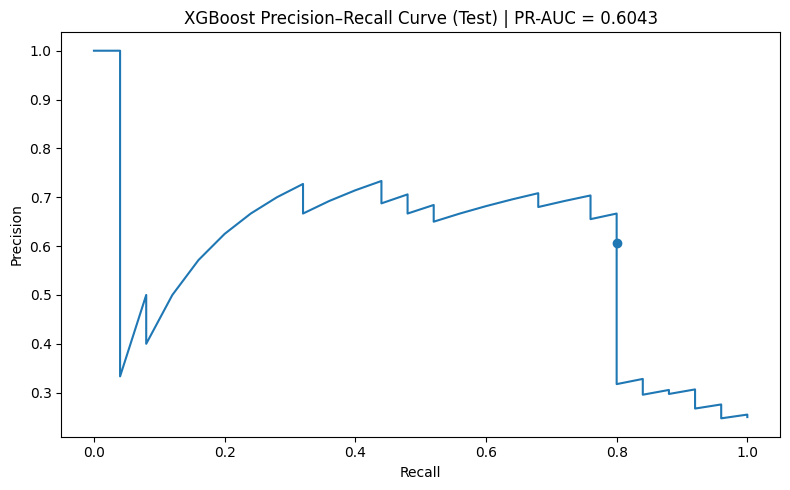

In [23]:
precision, recall, thresholds = precision_recall_curve(y_test, test_proba_xgb)

plt.figure(figsize = (8, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'XGBoost Precision–Recall Curve (Test) | PR-AUC = {pr_auc_xgb:.4f}')

idx_05 = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(recall[idx_05 + 1], precision[idx_05 + 1])

plt.tight_layout()
plt.savefig(save_dir / 'pr_curve_xgb_threshold_0_5.png', dpi = 200)
plt.show()

I visualise the precision–recall trade-off on the test set to understand how performance changes across different decision thresholds. I highlight the default threshold of 0.5 as the initial operating point, which helps me decide whether shifting the threshold can better match my objective of high fraud recall under a minimum precision constraint.

### Over-/Underfitting Check

In [21]:
train_proba_xgb = best_xgb.predict_proba(X_train)[:, 1]
test_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print('Train PR-AUC =', round(average_precision_score(y_train, train_proba_xgb), 4))
print('Test  PR-AUC =', round(average_precision_score(y_test, test_proba_xgb), 4))

train_pred_05 = (train_proba_xgb >= 0.5).astype(int)
test_pred_05 = (test_proba_xgb >= 0.5).astype(int)

print('\nTrain report (0.5)')
print(classification_report(y_train, train_pred_05, digits = 4))

print('\nTest report (0.5)')
print(classification_report(y_test, test_pred_05, digits = 4))

Train PR-AUC = 0.7206
Test  PR-AUC = 0.6043

Train report (0.5)
              precision    recall  f1-score   support

           0     0.9060    0.8525    0.8784       678
           1     0.6183    0.7297    0.6694       222

    accuracy                         0.8222       900
   macro avg     0.7621    0.7911    0.7739       900
weighted avg     0.8350    0.8222    0.8269       900


Test report (0.5)
              precision    recall  f1-score   support

           0     0.9242    0.8133    0.8652        75
           1     0.5882    0.8000    0.6780        25

    accuracy                         0.8100       100
   macro avg     0.7562    0.8067    0.7716       100
weighted avg     0.8402    0.8100    0.8184       100



I check for overfitting by comparing training and test performance using **PR-AUC and classification metrics** at the same threshold (0.5).<br> The model shows a moderate generalisation gap (Train PR-AUC = 0.7206 vs Test PR-AUC = 0.6043).<br> This suggests the current hyperparameter setting is better regularised and generalises more reliably, so I proceed with threshold optimisation on the validation split.

### Threshold Tuning

In [24]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, 
                                            y_train, 
                                            test_size = 0.2, 
                                            stratify = y_train, 
                                            random_state = 42)

In [25]:
xgb_clone = clone(best_xgb)

spw_clone = (y_tr == 0).sum() / (y_tr == 1).sum()
xgb_clone.set_params(scale_pos_weight = spw_clone)

print('Fitting XGB Model on training split for threshold tuning...')
xgb_clone.fit(X_tr, y_tr)

Fitting XGB Model on training split for threshold tuning...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [26]:
def threshold_opt_recall_with_precision(y_true,
                                        y_proba,
                                        precision_min = 0.35,
                                        plot = True,
                                        verbose = True,
                                        title = 'Threshold tuning',
                                        save_dir = None,
                                        save_plot = None):

    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    precision_t = precision[1:]
    recall_t = recall[1:]
    thr = thresholds

    mask = precision_t >= precision_min

    if mask.any():
        best_idx = int(np.argmax(recall_t[mask]))
        best_thr = float(thr[mask][best_idx])
    else:
        best_idx = int(np.argmax(recall_t))
        best_thr = float(thr[best_idx])

    best_precision = float(precision_t[np.where(thr == best_thr)[0][0]])
    best_recall = float(recall_t[np.where(thr == best_thr)[0][0]])

    if plot:

        plt.figure(figsize = (10, 6))
        plt.plot(thr, precision_t, label = 'Precision')
        plt.plot(thr, recall_t, label = 'Recall')
        plt.axvline(best_thr, linestyle = ':', label = f'Best threshold = {best_thr:.4f}')
        plt.axhline(precision_min, linestyle = '--', alpha = 0.7, label = f'Precision ≥ {precision_min:.2f}')
        plt.title(title)
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        if (save_dir is not None) and (save_plot is not None):
            plt.savefig(Path(save_dir) / f'{save_plot}.png', dpi = 200, bbox_inches = 'tight')

        plt.show()

    if verbose:
        print(f'Best threshold = {best_thr:.4f} | Val precision = {best_precision:.4f} | Val recall = {best_recall:.4f}')

    return best_thr, best_precision, best_recall

Make predictions on Valiation Set...


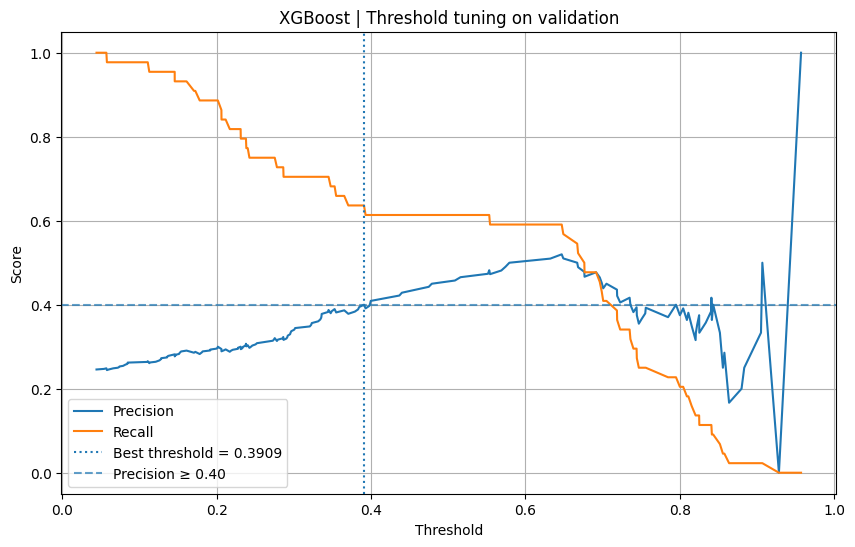

Best threshold = 0.3909 | Val precision = 0.4000 | Val recall = 0.6364


In [53]:
print('Make predictions on Valiation Set...')
val_proba_xgb = xgb_clone.predict_proba(X_val)[:, 1]

best_t_xgb, best_p_xgb, best_r_xgb = threshold_opt_recall_with_precision(
    y_true = y_val,
    y_proba = val_proba_xgb,
    precision_min = 0.40,
    plot = True,
    verbose = True,
    title = 'XGBoost | Threshold tuning on validation',
    save_dir = save_dir,
    save_plot = 'threshold_tuning_xgb'
)

In [37]:
test_pred_xgb_tuned = (test_proba_xgb >= best_t_xgb).astype(int)

print('\nConfusion Matrix (tuned threshold)')
print(confusion_matrix(y_test, test_pred_xgb_tuned))

print('\nClassification Report (tuned threshold)')
print(classification_report(y_test, test_pred_xgb_tuned, digits = 4))


Confusion Matrix (tuned threshold)
[[58 17]
 [ 5 20]]

Classification Report (tuned threshold)
              precision    recall  f1-score   support

           0     0.9206    0.7733    0.8406        75
           1     0.5405    0.8000    0.6452        25

    accuracy                         0.7800       100
   macro avg     0.7306    0.7867    0.7429       100
weighted avg     0.8256    0.7800    0.7917       100



I tested several thresholds around the default value to assess the stability of the operating point.<br> A lower threshold (0.40) maintains the same fraud recall (0.80) but increases the number of false positives, reducing overall precision and accuracy.<br> Since the default threshold of 0.5 already provides the best and most stable precision/recall trade-off on the test set, I keep 0.5 as the final operating point for XGBoost.

In [38]:
report_xgb_tuned = classification_report(y_test, test_pred_xgb_tuned, output_dict = True)
pd.DataFrame(report_xgb_tuned).T.to_csv(save_art / 'classification_report_xgb_tuned.csv', index = True)
print('Saving completed')

Saving completed


In [41]:
def metrics_at_threshold(y_true, y_proba, t):
    y_pred = (y_proba >= t).astype(int)
    return {
        'Threshold' : float(t),
        'Precision' : round(precision_score(y_true, y_pred, zero_division = 0), 3),
        'Recall' : round(recall_score(y_true, y_pred, zero_division = 0), 3),
        'F1' : round(f1_score(y_true, y_pred, zero_division = 0), 3),
        'Accuracy' : round(accuracy_score(y_true, y_pred), 3),
    }

In [42]:
results = []

results.append({
    'Model' : 'XGBoost - t = 0.50',
    **metrics_at_threshold(y_test, test_proba_xgb, 0.50)
})

results.append({
    'Model' : f'XGBoost - tuned t = {best_t_xgb:.3f}',
    **metrics_at_threshold(y_test, test_proba_xgb, best_t_xgb)
})

topt_eval = pd.DataFrame(results)
display(topt_eval)

,Model,Threshold,Precision,Recall,F1,Accuracy
0,XGBoost - t = 0.50,0.500000,0.588,0.8,0.678,0.81
1,XGBoost - tuned t = 0.391,0.390887,0.541,0.8,0.645,0.78


I compare the default threshold (0.5) with the tuned threshold obtained on the validation split.<br> The tuned threshold does not improve fraud recall on the test set (both achieve 0.80) but reduces fraud precision (0.588 → 0.541) and overall accuracy (0.81 → 0.78) due to additional false positives.<br> Therefore, I keep the default threshold of 0.5 as the final operating point for the XGBoost model.

In [43]:
topt_eval.to_csv(save_art / 'xgb_threshold_comparison.csv', index = False)
print('Saving completed')

Saving completed


## Model Interpretation

In this section I interpret the final XGBoost model to understand which features drive fraud predictions.<br> I use permutation importance (measured as the decrease in PR-AUC) and SHAP to obtain both global feature importance and directional effects. I run both analyses on the held-out test set to reflect generalisation on unseen data.

### Permutation Importance

Permutation importance measures the drop in Average Precision when a feature’s signal is destroyed (shuffled) on validation data.

In [45]:
perm = permutation_importance(
    best_xgb,
    X_test,
    y_test,
    n_repeats = 20,
    scoring = 'average_precision',
    random_state = 42,
)

perm_df = (pd.DataFrame({'feature': X_test.columns,
                         'importance_mean': perm.importances_mean,
                         'importance_std': perm.importances_std})
           .sort_values('importance_mean', ascending = False)
           .reset_index(drop = True))

display(perm_df.head(10))

,feature,importance_mean,importance_std
0,incident_severity,0.331057,0.041419
1,collision_type,0.019194,0.008966
2,months_as_customer,0.007448,0.013061
3,incident_type,0.005076,0.004131
4,property_share,0.002553,0.012669
5,property_damage,0.001100,0.005794
6,policy_deductable,0.000000,0.000000
7,has_umbrella_policy,0.000000,0.000000
8,total_claim_amount,-0.002360,0.014287
9,authorities_contacted,-0.005646,0.008805


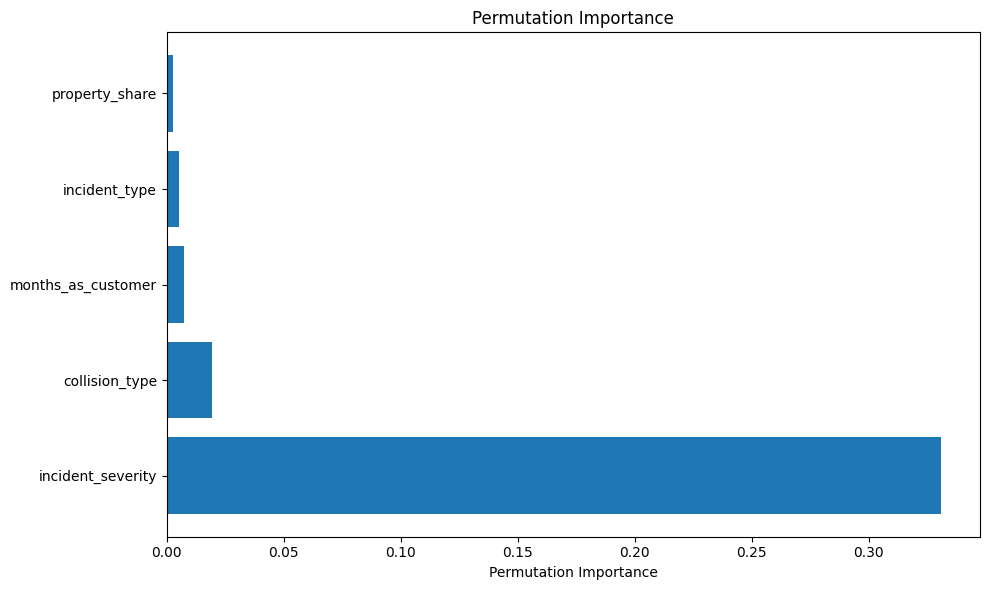

In [46]:
#top_n = 15
top_perm = perm_df.head()

plt.figure(figsize = (10,6))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.xlabel("Permutation Importance")
plt.title("Permutation Importance")
plt.tight_layout()
plt.savefig(save_dir / 'permutation_importance_xgb.png', dpi = 200)
plt.show()

In [47]:
perm_df.to_csv(save_art / 'perm_imp.csv', index = False)

### SHAP

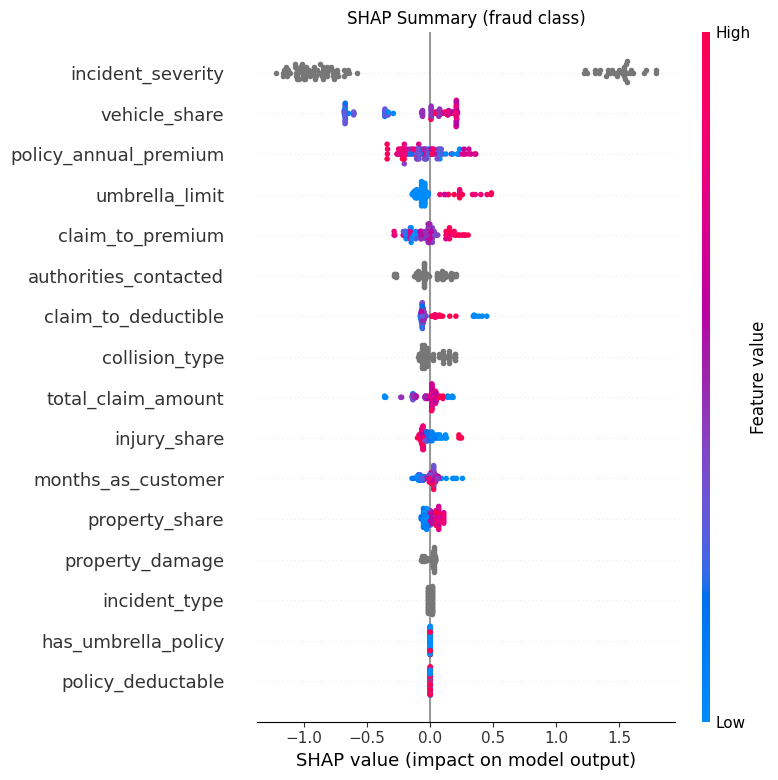

In [48]:

X_shap = X_test.copy()
X_shap_sample = X_shap.sample(n = min(300, len(X_shap)), random_state = 42)


explainer = shap.TreeExplainer(best_xgb)
shap_vals = explainer.shap_values(X_shap_sample) 

shap_vals_pos = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

plt.figure(figsize=(6,4))
shap.summary_plot(shap_vals_pos, X_shap_sample, feature_names = X_test.columns, show = False)
plt.title("SHAP Summary (fraud class)")
plt.tight_layout() 
plt.savefig(save_dir / 'SHAP_summary.png')
plt.show()

The SHAP summary confirms that `incident_severity` is the dominant driver of fraud predictions.<br> Higher severity levels push the model output strongly towards the fraud class for a subset of claims, while lower severity levels tend to reduce fraud probability.<br> Among the numeric ratio features, higher `vehicle_share`, higher `umbrella_limit`, and higher `claim_to_premium` are generally associated with higher fraud scores, whereas lower values of these features tend to decrease the fraud prediction.<br> I also observe smaller but consistent effects for `claim_to_deductible` and `total_claim_amount`, suggesting that the model uses both incident context and claim-size related signals to refine its fraud ranking.<br> I interpret these relationships as model associations on this dataset rather than causal effects.

In [51]:
models_dir = Path('../models/xgboost')
models_dir.mkdir(parents = True, exist_ok = True)

model_path = models_dir / 'xgb_model.joblib'
meta_path = models_dir / 'xgb_meta.json'

dump(best_xgb, model_path, compress = 3)

meta_xgb = {
    'sklearn_version' : sklearn.__version__,
    'python' : sys.version.split()[0],
    'platform' : platform.platform(),
    'model_type' : 'XGBClassifier',
    'threshold' : 0.50,
    'target_metric' : 'PR-AUC (test) + Fraud precision/recall trade-off',
    'notes' : 'Final operating point kept at default threshold because tuned thresholds did not generalise.'
}

with open(meta_path, 'w') as f:
    json.dump(meta_xgb, f, indent = 2)

print('Saved model to:', model_path)
print('Saved metadata to:', meta_path)

Saved model to: ..\models\xgboost\xgb_model.joblib
Saved metadata to: ..\models\xgboost\xgb_meta.json


In [52]:
model_path = Path('../models/xgboost/xgb_model.joblib')
meta_path = Path('../models/xgboost/xgb_meta.json')

xgb_loaded = load(model_path)

with open(meta_path, 'r') as f:
    meta_loaded = json.load(f)

print('Loaded model:', type(xgb_loaded))
print('Loaded threshold:', meta_loaded.get('threshold'))

Loaded model: <class 'xgboost.sklearn.XGBClassifier'>
Loaded threshold: 0.5
